In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

import pickle

In [2]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/y_test.csv").values.ravel()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (40000, 14)
X_test: (10000, 14)


In [3]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    # Sigmoid converts values into probability between 0 and 1
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Train model using gradient descent
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.epochs):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            # Gradient calculation
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Calculate loss
            loss = -np.mean(
                y * np.log(y_predicted + 1e-9) +
                (1 - y) * np.log(1 - y_predicted + 1e-9)
            )
            self.loss_history.append(loss)

    # Return probabilities
    def predict_proba(self, X):
        X = np.array(X)
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    # Convert probability to class
    def predict(self, X):
        probabilities = self.predict_proba(X)
        return np.where(probabilities >= 0.5, 1, 0)

In [4]:
model = LogisticRegressionScratch(
    learning_rate=0.01,
    epochs=1000
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


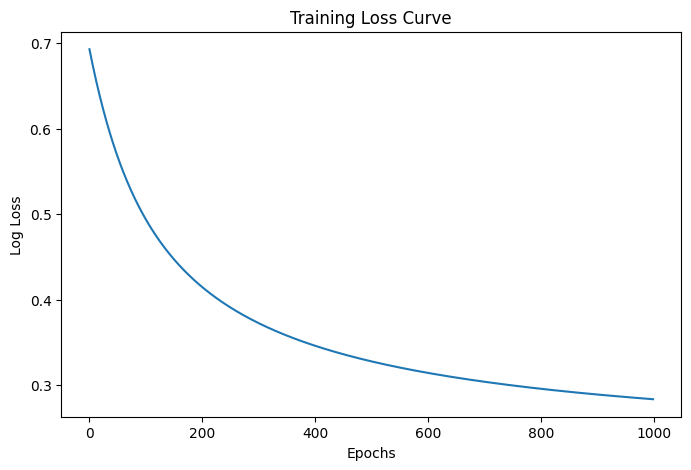

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(model.loss_history)

plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")

plt.show()

In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8869

Confusion Matrix:
[[4425  575]
 [ 556 4444]]


In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      5000
           1       0.89      0.89      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



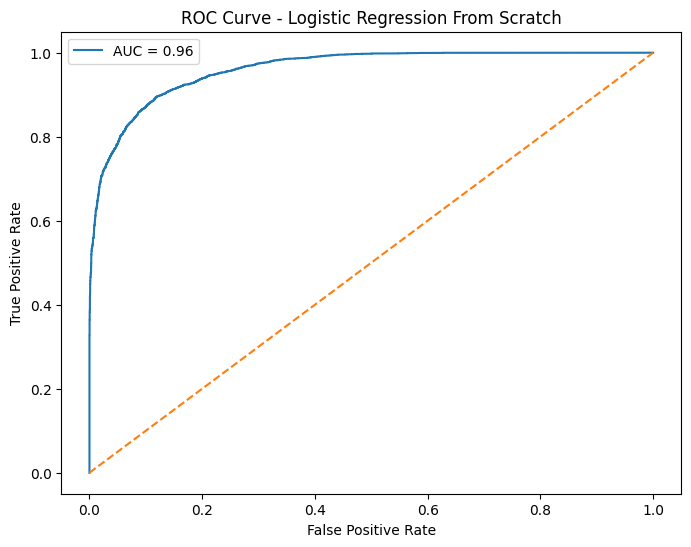

AUC Score: 0.9604


In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Logistic Regression From Scratch")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

print("AUC Score:", round(roc_auc, 4))

In [10]:
model_data = {
    "weights": model.weights,
    "bias": model.bias,
    "learning_rate": model.learning_rate,
    "epochs": model.epochs
}

with open("../models/logistic_regression_scratch.pkl", "wb") as file:
    pickle.dump(model_data, file)

print("Scratch model saved successfully.")

Scratch model saved successfully.


### Final Model Summary

Logistic Regression was selected after model comparison because it achieved the best performance.

The final model was implemented from scratch using:
- Sigmoid function
- Binary cross-entropy loss
- Gradient descent
- Weight and bias update

The model was evaluated using accuracy, confusion matrix, classification report, ROC curve, and AUC score.